In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv("Social_Media_Advertising.csv")

# First look
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (300000, 16)

Column names:
['Campaign_ID', 'Target_Audience', 'Campaign_Goal', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date', 'Company']

First 5 rows:
   Campaign_ID Target_Audience     Campaign_Goal Duration Channel_Used  \
0       529013       Men 35-44    Product Launch  15 Days    Instagram   
1       275352     Women 45-60  Market Expansion  15 Days     Facebook   
2       692322       Men 45-60    Product Launch  15 Days    Instagram   
3       675757       Men 25-34    Increase Sales  15 Days    Pinterest   
4       535900       Men 45-60  Market Expansion  15 Days    Pinterest   

   Conversion_Rate Acquisition_Cost       ROI     Location Language  Clicks  \
0             0.15          $500.00  5.790000    Las Vegas  Spanish     500   
1             0.01          $500.00  7.210000  Los Angeles   French     500   
2             0.08          $500.0

In [3]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Data types:
Campaign_ID           int64
Target_Audience      object
Campaign_Goal        object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
Company              object
dtype: object

Missing values:
Campaign_ID         0
Target_Audience     0
Campaign_Goal       0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
Company             0
dtype: int64


In [4]:
# Fix Acquisition_Cost - remove $ sign and convert to float
df["Acquisition_Cost"] = df["Acquisition_Cost"].str.replace("$", "").str.replace(",", "").astype(float)

# Fix Date - convert to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Verify the fixes
print("Acquisition_Cost dtype:", df["Acquisition_Cost"].dtype)
print("Date dtype:", df["Date"].dtype)
print("\nSample:")
print(df[["Acquisition_Cost", "Date"]].head())

Acquisition_Cost dtype: float64
Date dtype: datetime64[ns]

Sample:
   Acquisition_Cost       Date
0             500.0 2022-02-25
1             500.0 2022-05-12
2             500.0 2022-06-19
3             500.0 2022-09-08
4             500.0 2022-08-24


In [5]:
# Summary of key metrics
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total campaigns: {df['Campaign_ID'].nunique():,}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Platforms: {df['Channel_Used'].unique().tolist()}")
print(f"Campaign goals: {df['Campaign_Goal'].unique().tolist()}")
print(f"Customer segments: {df['Customer_Segment'].unique().tolist()}")
print(f"\nAverage ROI: {df['ROI'].mean():.2f}")
print(f"Average Conversion Rate: {df['Conversion_Rate'].mean():.2%}")
print(f"Average Acquisition Cost: ${df['Acquisition_Cost'].mean():.2f}")
print(f"Average Engagement Score: {df['Engagement_Score'].mean():.2f}")

DATASET OVERVIEW
Total campaigns: 255,092
Date range: 2022-01-01 to 2022-12-31
Platforms: ['Instagram', 'Facebook', 'Pinterest', 'Twitter']
Campaign goals: ['Product Launch', 'Market Expansion', 'Increase Sales', 'Brand Awareness']
Customer segments: ['Health', 'Home', 'Technology', 'Food', 'Fashion']

Average ROI: 3.18
Average Conversion Rate: 8.00%
Average Acquisition Cost: $7753.75
Average Engagement Score: 4.37


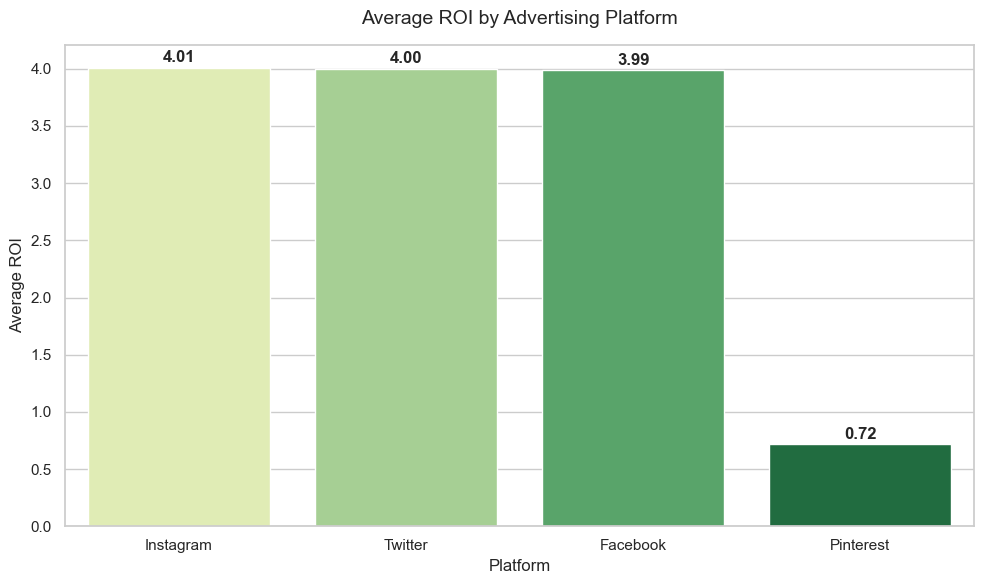


ROI by platform:
Channel_Used
Instagram    4.008786
Twitter      4.002236
Facebook     3.986930
Pinterest    0.716431
Name: ROI, dtype: float64


In [6]:
# ROI by platform
platform_roi = df.groupby("Channel_Used")["ROI"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=platform_roi.index, y=platform_roi.values,
                   palette="YlGn")

# Add value labels on top of each bar
for i, v in enumerate(platform_roi.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")

plt.title("Average ROI by Advertising Platform", fontsize=14, pad=15)
plt.xlabel("Platform")
plt.ylabel("Average ROI")
plt.tight_layout()
plt.savefig("roi_by_platform.png", dpi=150)
plt.show()

print("\nROI by platform:")
print(platform_roi)

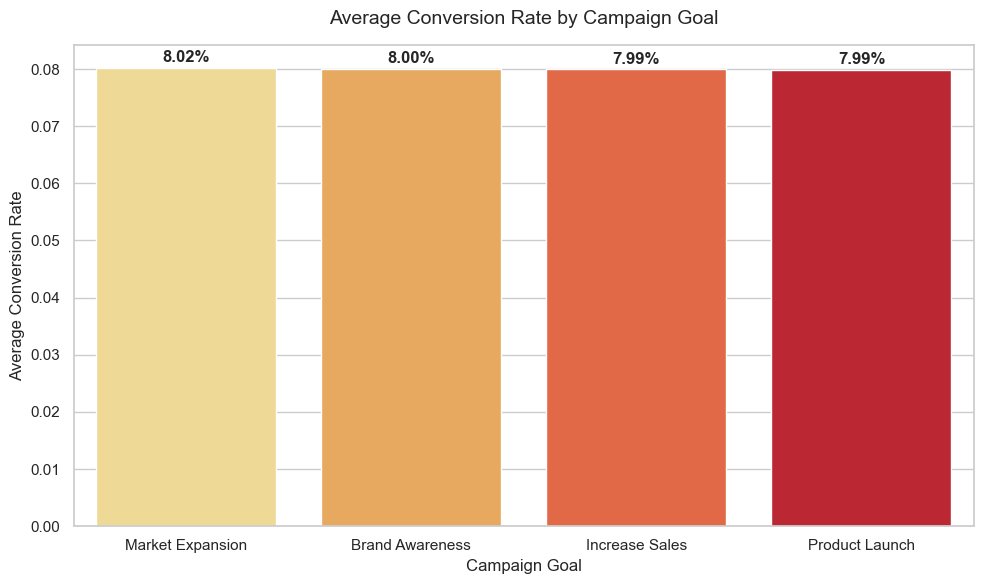


Conversion rate by goal:
Campaign_Goal
Market Expansion    0.080220
Brand Awareness     0.079995
Increase Sales      0.079929
Product Launch      0.079894
Name: Conversion_Rate, dtype: float64


In [7]:
# Conversion rate by campaign goal
goal_conv = df.groupby("Campaign_Goal")["Conversion_Rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=goal_conv.index, y=goal_conv.values, palette="YlOrRd")

for i, v in enumerate(goal_conv.values):
    plt.text(i, v + 0.001, f"{v:.2%}", ha="center", fontweight="bold")

plt.title("Average Conversion Rate by Campaign Goal", fontsize=14, pad=15)
plt.xlabel("Campaign Goal")
plt.ylabel("Average Conversion Rate")
plt.tight_layout()
plt.savefig("conversion_by_goal.png", dpi=150)
plt.show()

print("\nConversion rate by goal:")
print(goal_conv)

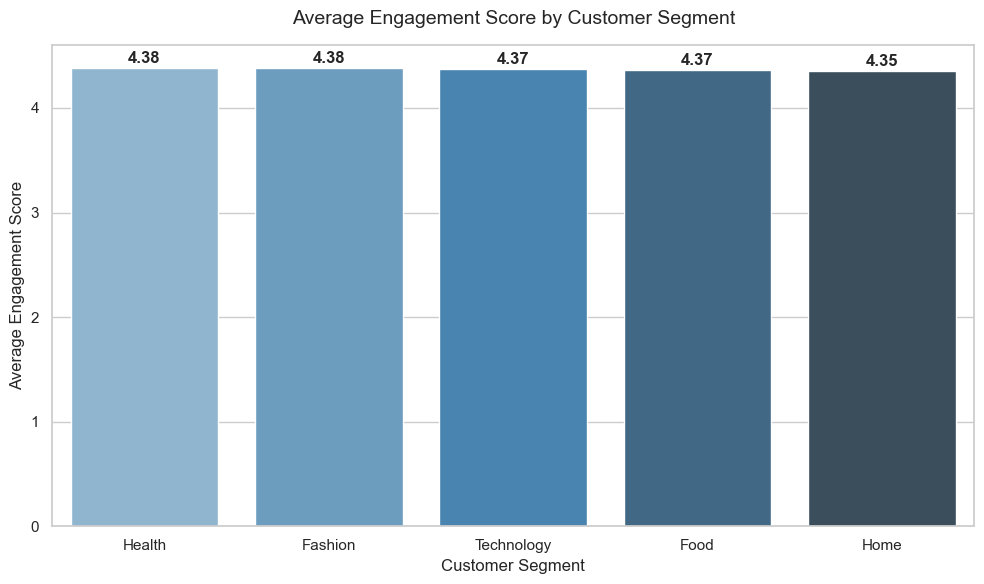


Engagement by segment:
Customer_Segment
Health        4.384532
Fashion       4.379062
Technology    4.368633
Food          4.365020
Home          4.348852
Name: Engagement_Score, dtype: float64


In [8]:
# Engagement score by customer segment
segment_eng = df.groupby("Customer_Segment")["Engagement_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_eng.index, y=segment_eng.values, palette="Blues_d")

for i, v in enumerate(segment_eng.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")

plt.title("Average Engagement Score by Customer Segment", fontsize=14, pad=15)
plt.xlabel("Customer Segment")
plt.ylabel("Average Engagement Score")
plt.tight_layout()
plt.savefig("engagement_by_segment.png", dpi=150)
plt.show()

print("\nEngagement by segment:")
print(segment_eng)

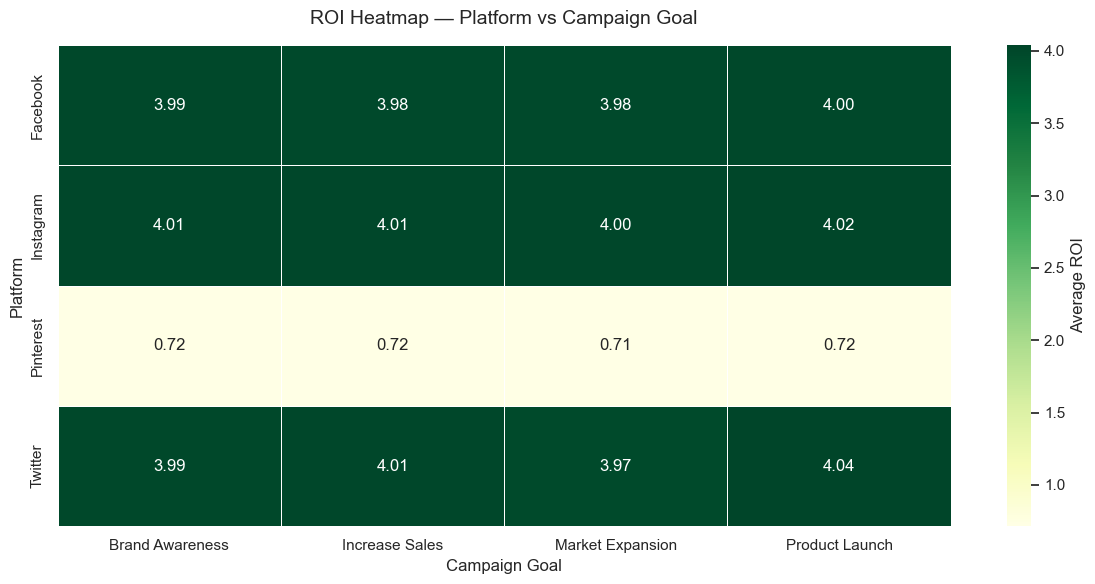

In [9]:
# Heatmap - ROI by platform and campaign goal
pivot = df.pivot_table(values="ROI", 
                        index="Channel_Used", 
                        columns="Campaign_Goal", 
                        aggfunc="mean")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGn", 
            linewidths=0.5, cbar_kws={"label": "Average ROI"})

plt.title("ROI Heatmap — Platform vs Campaign Goal", fontsize=14, pad=15)
plt.xlabel("Campaign Goal")
plt.ylabel("Platform")
plt.tight_layout()
plt.savefig("roi_heatmap.png", dpi=150)
plt.show()

In [10]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Finding 1 - Platform ROI
best_platform = df.groupby("Channel_Used")["ROI"].mean().idxmax()
worst_platform = df.groupby("Channel_Used")["ROI"].mean().idxmin()
best_roi = df.groupby("Channel_Used")["ROI"].mean().max()
worst_roi = df.groupby("Channel_Used")["ROI"].mean().min()

print(f"\n1. PLATFORM PERFORMANCE")
print(f"   {best_platform} delivers the highest average ROI ({best_roi:.2f})")
print(f"   {worst_platform} consistently underperforms ({worst_roi:.2f} ROI)")
print(f"   across all campaign goals — suggesting budget reallocation")
print(f"   away from {worst_platform} could improve overall returns.")

# Finding 2 - Campaign goals
max_conv = df.groupby("Campaign_Goal")["Conversion_Rate"].mean().max()
min_conv = df.groupby("Campaign_Goal")["Conversion_Rate"].mean().min()
diff = max_conv - min_conv

print(f"\n2. CAMPAIGN GOALS DON'T DRIVE CONVERSION")
print(f"   All four campaign goals convert within {diff:.4f} of each other.")
print(f"   Conversion rate appears independent of campaign objective,")
print(f"   suggesting audience targeting and creative quality matter more.")

# Finding 3 - Segments
best_segment = df.groupby("Customer_Segment")["Engagement_Score"].mean().idxmax()
worst_segment = df.groupby("Customer_Segment")["Engagement_Score"].mean().idxmin()

print(f"\n3. ENGAGEMENT IS UNIFORM ACROSS SEGMENTS")
print(f"   {best_segment} leads engagement but only marginally ahead of")
print(f"   {worst_segment} at the bottom — a difference of less than 0.04.")
print(f"   No single segment dominates, meaning broad targeting strategies")
print(f"   may be as effective as highly segmented campaigns.")

# Finding 4 - Pinterest
pinterest_roi = df[df["Channel_Used"] == "Pinterest"]["ROI"].mean()
overall_roi = df["ROI"].mean()
gap = ((overall_roi - pinterest_roi) / overall_roi) * 100

print(f"\n4. PINTEREST BUDGET EFFICIENCY")
print(f"   Pinterest ROI ({pinterest_roi:.2f}) sits {gap:.1f}% below")
print(f"   the overall campaign average ({overall_roi:.2f}).")
print(f"   Consistent underperformance across all goals and segments")
print(f"   makes it the clearest candidate for budget reallocation.")

print("\n" + "=" * 60)

KEY FINDINGS

1. PLATFORM PERFORMANCE
   Instagram delivers the highest average ROI (4.01)
   Pinterest consistently underperforms (0.72 ROI)
   across all campaign goals — suggesting budget reallocation
   away from Pinterest could improve overall returns.

2. CAMPAIGN GOALS DON'T DRIVE CONVERSION
   All four campaign goals convert within 0.0003 of each other.
   Conversion rate appears independent of campaign objective,
   suggesting audience targeting and creative quality matter more.

3. ENGAGEMENT IS UNIFORM ACROSS SEGMENTS
   Health leads engagement but only marginally ahead of
   Home at the bottom — a difference of less than 0.04.
   No single segment dominates, meaning broad targeting strategies
   may be as effective as highly segmented campaigns.

4. PINTEREST BUDGET EFFICIENCY
   Pinterest ROI (0.72) sits 77.5% below
   the overall campaign average (3.18).
   Consistent underperformance across all goals and segments
   makes it the clearest candidate for budget reallocation

In [11]:
df.to_csv("social_media_ad_analysis.csv", index=False)
print("Dataset saved!")

import os
for f in os.listdir("."):
    if not f.startswith("."):
        print(f" - {f}")

Dataset saved!
 - Social_Media_Advertising.csv
 - social_media_ad_analysis.csv
 - roi_heatmap.png
 - social-media-ad-analysis.ipynb
 - conversion_by_goal.png
 - engagement_by_segment.png
 - roi_by_platform.png
